
---

# ***`PCA Implementation`***

---


### **Import Libraries**

In [1]:
import os
import time
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


import warnings
warnings.filterwarnings("ignore")

### **Load the Dataset**

In [2]:
df = pd.read_csv(r'E:\Data Science Materials\100 days of Machine Learning CampusX\data\mnist_train.csv')

### **Check shape of the Data**

In [3]:
df.shape

(42000, 785)

In [4]:
# a sample from data
df.sample(2)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
15102,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31771,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### **Plot an Image**

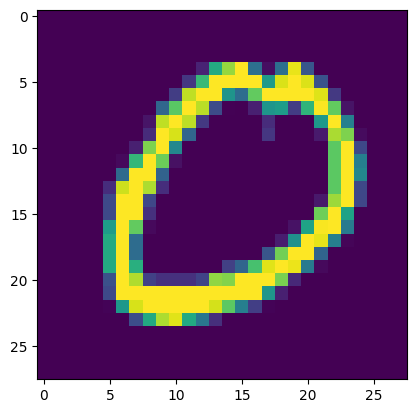

In [5]:
plt.imshow(df.iloc[13051,1:].values.reshape(28,28))
plt.show()

### **Spliting Data in X and y variables**

In [6]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

### **Train test Spliting the Data**

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
# check shape of X_train
X_train.shape

(33600, 784)

### **Use KNN on Data**

In [9]:
knn = KNeighborsClassifier()

### **Fit KNN on training Data**

In [10]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

### **Measure KNN Prediction Time on Data**

In [11]:
start = time.time()
y_pred = knn.predict(X_test)
print(time.time() - start)

23.020411491394043


### **Measure Accuracy of KNN on Data**

In [12]:
accuracy_score(y_test,y_pred)

0.9648809523809524

### **Use StandardScaler on Data**

In [13]:
scaler = StandardScaler()

### **Scale the data using StandardScaler**

In [14]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **Initialize PCA**

In [15]:
pca = PCA(n_components=200)

### **Implement PCA on Transformed Data**

In [16]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [17]:
# check X_train transformed shape
X_train_trf.shape

(33600, 200)

### **Initialize KNN for Transformed Data**

In [18]:
knn = KNeighborsClassifier()

### **Fit KNN for Transformed Data**

In [19]:
knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

### **Predict KNN for Transformed Data**

In [20]:
y_pred = knn.predict(X_test_trf)

### **Measure KNN Accuracy for Transformed Data**

In [21]:
accuracy_score(y_test,y_pred)

0.9507142857142857

### **PCA and KNN Classifier Implementation with Accuracy Evaluation**

In [22]:
# # Iterate over a range of number of components for PCA from 1 to 784
# for i in range(1, 785):
#     # Initialize PCA with the current number of components
#     pca = PCA(n_components=i)
    
#     # Fit PCA on the training data and transform it
#     X_train_trf = pca.fit_transform(X_train)
    
#     # Transform the test data using the fitted PCA
#     X_test_trf = pca.transform(X_test)
    
#     # Initialize the K-Nearest Neighbors classifier
#     knn = KNeighborsClassifier()
    
#     # Fit the KNN model on the transformed training data
#     knn.fit(X_train_trf, y_train)
    
#     # Predict the labels for the transformed test data
#     y_pred = knn.predict(X_test_trf)
    
#     # Print the accuracy score of the predictions compared to the actual test labels
#     print(accuracy_score(y_test, y_pred))

### **Visualize the Data in `2D` or `3D`**

In [23]:
# transforming to a 2D coordinate system
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [24]:
X_train_trf

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]])

In [25]:
import plotly.express as px


%matplotlib inline 

# Convert y_train to string type for coloring in the scatter plot
y_train_trf = y_train.astype(str)

# Create a scatter plot using Plotly Express
fig = px.scatter(
    x=X_train_trf[:, 0],
    y=X_train_trf[:, 1],
    color=y_train_trf,
    color_discrete_sequence=px.colors.qualitative.G10
)

# Show the figure
fig.show()

In [26]:
# transforming in 3D
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [27]:
X_train_trf

array([[-2.71863253, -0.48982409,  1.1354966 ],
       [-0.67698015, -6.75362491, -2.33590139],
       [-3.03323281,  6.50981624,  7.49182983],
       ...,
       [ 2.14883643,  0.78079444, -0.74738774],
       [ 1.05957006,  0.94767312,  3.94973114],
       [17.70258446,  1.96188185, -4.94352837]])

In [28]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=X_train_trf[:,0], y=X_train_trf[:,1], z=X_train_trf[:,2],
              color=y_train_trf)
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue",
)
fig.show()

### **Eigen values**

In [29]:
pca.explained_variance_

array([40.67111198, 29.17023401, 26.74459621])

### **Eigen vectors**

In [30]:
pca.components_

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]])

In [31]:
pca.components_.shape

(3, 784)

In [32]:
pca.explained_variance_ratio_

array([0.05785192, 0.0414927 , 0.03804239])

In [33]:
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [34]:
pca.explained_variance_.shape

(784,)

In [35]:
pca.components_.shape

(784, 784)

In [36]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

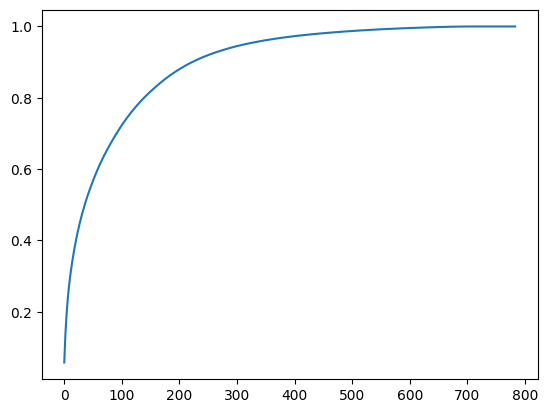

In [38]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.show()

---